# Geneformer: zero-shot vs finetuned (AUPRC)

Compare frozen (zero-shot) and finetuned Geneformer checkpoints on shared classification tasks:

- **GF-V1**: `V1-10M-i2048` vs `V1-10M-i2048_finetune`
- **GF-V2**: `V2-104M-i4096` vs `V2-104M-i4096_finetune`

Each task uses 5-fold cross-validation. Finetuned runs only export **MIL** CV metrics, so both variants are compared with the MIL aggregation strategy for a fair comparison.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import wilcoxon

from analysis_utils import EXPERIMENT_NAME_MAP

In [6]:
GENEFORMER_ROOT = Path("/home/haitham/mnt/__output_v8/exp/geneformer")
PLOTS_DIR = Path("./plots")
RESULTS_DIR = Path("./results/finetune_vs_frozen")
PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY = "MIL"  # finetuned runs only have MIL CV outputs

MODEL_PAIRS = [
    {
        "frozen_dir": "V1-10M-i2048",
        "finetune_dir": "V1-10M-i2048_finetune",
        "frozen_label": "GF-V1",
        "finetune_label": "GF-V1 [finetune]",
    },
    {
        "frozen_dir": "V2-104M-i4096",
        "finetune_dir": "V2-104M-i4096_finetune",
        "frozen_label": "GF-V2",
        "finetune_label": "GF-V2 [finetune]",
    },
]

CV_METRICS_FILENAMES = {
    "vote": ["vote_cv_metrics.csv", "votecv_metrics.csv"],
    "MIL": ["mil_cv_metrics.csv", "milcv_metrics.csv"],
}

SKIP_SUBSTR = ("arxiv", "continue", "cell_type", "full", ".ipynb_checkpoints")

In [7]:
def task_key(run_dir_name: str) -> str:
    """Extract task id, e.g. brca_chemo from brca_chemo_geneformer_V1-...."""
    return run_dir_name.split("_geneformer_")[0]


def find_cv_metrics(run_dir: Path, strategy: str) -> Path | None:
    cv_dir = run_dir / "cv"
    for fname in CV_METRICS_FILENAMES[strategy]:
        path = cv_dir / fname
        if path.exists():
            return path
    return None


def read_auprc_folds(run_dir: Path, strategy: str) -> pd.Series | None:
    """Return per-fold AUPRC values for a single run directory."""
    metrics_path = find_cv_metrics(run_dir, strategy)
    if metrics_path is None:
        return None

    df = pd.read_csv(metrics_path)
    score_cols = [c for c in df.columns if c not in {"Metrics", "fold"}]
    if not score_cols:
        return None

    score_col = "randomforest" if "randomforest" in score_cols else score_cols[0]
    values = df.loc[df["Metrics"] == "AUPRC", score_col].astype(float)
    if values.empty:
        return None

    values.index = range(1, len(values) + 1)
    return values


def list_run_dirs(model_dir: Path) -> dict[str, Path]:
    runs = {}
    for path in sorted(model_dir.iterdir()):
        if not path.is_dir():
            continue
        if any(s in path.name for s in SKIP_SUBSTR):
            continue
        runs[task_key(path.name)] = path
    return runs


def collect_pair_metrics(pair: dict, strategy: str = STRATEGY) -> pd.DataFrame:
    frozen_runs = list_run_dirs(GENEFORMER_ROOT / pair["frozen_dir"])
    finetune_runs = list_run_dirs(GENEFORMER_ROOT / pair["finetune_dir"])
    common_tasks = sorted(set(frozen_runs) & set(finetune_runs))

    rows = []
    for task in common_tasks:
        exp_display = EXPERIMENT_NAME_MAP.get(task, task)
        for variant, label, run_dir in [
            ("zero_shot", pair["frozen_label"], frozen_runs[task]),
            ("finetune", pair["finetune_label"], finetune_runs[task]),
        ]:
            folds = read_auprc_folds(run_dir, strategy)
            if folds is None:
                print(f"Missing {strategy} AUPRC: {run_dir}")
                continue
            for fold, auprc in folds.items():
                rows.append(
                    {
                        "task": task,
                        "exp_display": exp_display,
                        "model": label,
                        "variant": variant,
                        "fold": fold,
                        "AUPRC": auprc,
                        "run_dir": str(run_dir),
                    }
                )
    return pd.DataFrame(rows)

In [8]:
def summarize_by_task(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["task", "exp_display", "model", "variant"], as_index=False)["AUPRC"]
        .agg(mean_auprc="mean", std_auprc="std", n_folds="count")
    )


def build_comparison_table(summary: pd.DataFrame, frozen_label: str, finetune_label: str) -> pd.DataFrame:
    pivot = summary.pivot(index="exp_display", columns="model", values="mean_auprc")
    table = pivot[[frozen_label, finetune_label]].dropna().copy()
    table["delta"] = table[finetune_label] - table[frozen_label]
    table["finetune_better"] = table["delta"] > 0
    return table.sort_index()


def build_stats_row(
    table: pd.DataFrame,
    frozen_label: str,
    finetune_label: str,
    model_pair: str,
    strategy: str,
    statistic: float,
    p_value: float,
) -> dict:
    delta = table["delta"]
    return {
        "model_pair": model_pair,
        "strategy": strategy,
        "n_tasks": len(table),
        "wilcoxon_statistic": statistic,
        "wilcoxon_p_value": p_value,
        "mean_delta_auprc": delta.mean(),
        "median_delta_auprc": delta.median(),
        "n_finetune_better": int((delta > 0).sum()),
        "n_finetune_worse": int((delta < 0).sum()),
        "n_tie": int((delta == 0).sum()),
        "mean_zero_shot_auprc": table[frozen_label].mean(),
        "mean_finetune_auprc": table[finetune_label].mean(),
    }


def save_comparison_tables(
    metrics_df: pd.DataFrame,
    result: dict,
    pair: dict,
    strategy: str = STRATEGY,
    results_dir: Path = RESULTS_DIR,
) -> None:
    """Write fold-level, task-summary, comparison, and stats tables to disk."""
    model_pair = f"{pair['frozen_label']} vs {pair['finetune_label']}"
    slug = pair["frozen_label"].replace(" ", "_").replace("[", "").replace("]", "")

    fold_path = results_dir / f"{slug}_fold_level_auprc.csv"
    metrics_df.to_csv(fold_path, index=False)

    summary = result["summary"].copy()
    summary["model_pair"] = model_pair
    summary["strategy"] = strategy
    summary_path = results_dir / f"{slug}_task_summary.csv"
    summary.to_csv(summary_path, index=False)

    comparison = result["table"].reset_index().rename(columns={"exp_display": "task_name"})
    comparison["model_pair"] = model_pair
    comparison["strategy"] = strategy
    comparison = comparison.rename(
        columns={
            pair["frozen_label"]: "zero_shot_auprc",
            pair["finetune_label"]: "finetune_auprc",
        }
    )
    comparison_path = results_dir / f"{slug}_comparison.csv"
    comparison.to_csv(comparison_path, index=False)

    stats_row = build_stats_row(
        result["table"],
        pair["frozen_label"],
        pair["finetune_label"],
        model_pair,
        strategy,
        result["statistic"],
        result["p_value"],
    )
    stats_path = results_dir / f"{slug}_stats.csv"
    pd.DataFrame([stats_row]).to_csv(stats_path, index=False)

    print(f"Saved tables for {model_pair}:")
    print(f"  {fold_path.name}")
    print(f"  {summary_path.name}")
    print(f"  {comparison_path.name}")
    print(f"  {stats_path.name}")


def compare_and_plot(
    df: pd.DataFrame,
    frozen_label: str,
    finetune_label: str,
    strategy: str = STRATEGY,
    save_dir: Path = PLOTS_DIR,
):
    """Paired task-level comparison with Wilcoxon signed-rank test."""
    summary = summarize_by_task(df)
    table = build_comparison_table(summary, frozen_label, finetune_label)

    vals_frozen = table[frozen_label]
    vals_ft = table[finetune_label]
    stat, p_value = wilcoxon(vals_ft, vals_frozen)

    fig, ax = plt.subplots(figsize=(6, 6))
    for y0, y1 in zip(vals_frozen, vals_ft):
        ax.plot([0, 1], [y0, y1], color="gray", alpha=0.5, zorder=1)

    ax.scatter([0] * len(vals_frozen), vals_frozen, label=frozen_label, alpha=0.85, s=70, zorder=2)
    ax.scatter([1] * len(vals_ft), vals_ft, label=finetune_label, alpha=0.85, s=70, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{frozen_label}\n(zero-shot)", finetune_label], fontsize=12)
    ax.set_ylabel("Mean AUPRC (5-fold CV)", fontsize=14)
    ax.set_title(
        f"{frozen_label} vs {finetune_label} ({strategy})\n"
        f"Wilcoxon signed-rank p = {p_value:.4f}"
    )
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    plt.tight_layout()

    fname = save_dir / f"{frozen_label}_vs_{finetune_label}_{strategy}.png"
    fig.savefig(fname, dpi=150)
    plt.show()

    return {"statistic": stat, "p_value": p_value, "table": table, "summary": summary}


GF-V1 vs GF-V1 [finetune]
  tasks: 7, fold rows: 68


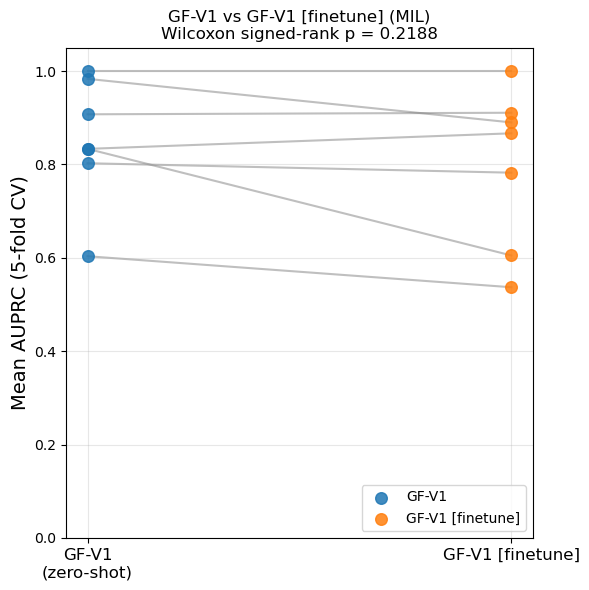

Saved tables for GF-V1 vs GF-V1 [finetune]:
  GF-V1_fold_level_auprc.csv
  GF-V1_task_summary.csv
  GF-V1_comparison.csv
  GF-V1_stats.csv


model,GF-V1,GF-V1 [finetune],delta,finetune_better
exp_display,,,,
ER+ vs TNBC,0.983,0.890,-0.093,False
IO Response,0.833,0.867,0.033,True
MMRd vs MMRp,0.803,0.782,-0.020,False
T-cell exhaustion,0.833,0.605,-0.228,False
Treatment Naive vs Anti PD1,0.907,0.911,0.003,True
Treatment Naive vs Neoadjuvant Chemo,0.603,0.537,-0.066,False
Treatment Naive vs TKI treated,1.000,1.000,0.000,False


Missing MIL AUPRC: /home/haitham/mnt/__output_v8/exp/geneformer/V2-104M-i4096_finetune/brca_chemo_geneformer_V2-104M-i4096_finetune_brca_chemo
Missing MIL AUPRC: /home/haitham/mnt/__output_v8/exp/geneformer/V2-104M-i4096_finetune/brca_outcome_geneformer_V2-104M-i4096_finetune_brca_outcome

GF-V2 vs GF-V2 [finetune]
  tasks: 3, fold rows: 20


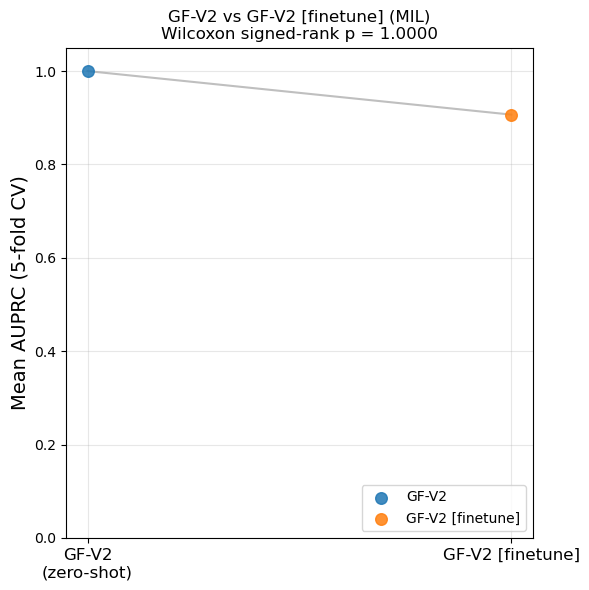

Saved tables for GF-V2 vs GF-V2 [finetune]:
  GF-V2_fold_level_auprc.csv
  GF-V2_task_summary.csv
  GF-V2_comparison.csv
  GF-V2_stats.csv


model,GF-V2,GF-V2 [finetune],delta,finetune_better
exp_display,,,,
ER+ vs TNBC,1.0,0.907,-0.093,False



Combined outputs written to /home/haitham/scFM_eval/analysis/classification/results/finetune_vs_frozen


,model_pair,strategy,n_tasks,wilcoxon_statistic,wilcoxon_p_value,mean_delta_auprc,median_delta_auprc,n_finetune_better,n_finetune_worse,n_tie,mean_zero_shot_auprc,mean_finetune_auprc
0,GF-V1 vs GF-V1 [finetune],MIL,7,4.0,0.2188,-0.0531,-0.0202,2,4,1,0.8519,0.7988
1,GF-V2 vs GF-V2 [finetune],MIL,1,0.0,1.0000,-0.0933,-0.0933,0,1,0,1.0000,0.9067


In [9]:
all_metrics = []
comparison_results = {}
stats_rows = []

for pair in MODEL_PAIRS:
    key = f"{pair['frozen_label']} vs {pair['finetune_label']}"
    metrics_df = collect_pair_metrics(pair, strategy=STRATEGY)
    all_metrics.append(metrics_df.assign(model_pair=key))

    print(f"\n{key}")
    print(f"  tasks: {metrics_df['task'].nunique()}, fold rows: {len(metrics_df)}")

    result = compare_and_plot(
        metrics_df,
        pair["frozen_label"],
        pair["finetune_label"],
        strategy=STRATEGY,
    )
    comparison_results[key] = result
    save_comparison_tables(metrics_df, result, pair, strategy=STRATEGY)

    stats_rows.append(
        build_stats_row(
            result["table"],
            pair["frozen_label"],
            pair["finetune_label"],
            key,
            STRATEGY,
            result["statistic"],
            result["p_value"],
        )
    )
    display(result["table"].round(3))

compare_df = pd.concat(all_metrics, ignore_index=True)
stats_df = pd.DataFrame(stats_rows)

compare_df.to_csv(RESULTS_DIR / "all_pairs_fold_level_auprc.csv", index=False)
stats_df.to_csv(RESULTS_DIR / "all_pairs_stats.csv", index=False)

print(f"\nCombined outputs written to {RESULTS_DIR.resolve()}")
display(stats_df.round(4))

In [22]:
# Long-format table kept at repo root for backward compatibility
compare_df.to_csv("finetune_vs_frozen_gf_v1_2.csv", index=False)
compare_df.head(10)

,task,exp_display,model,variant,fold,AUPRC,run_dir,model_pair
0,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1,zero_shot,1,1.000000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
1,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1,zero_shot,2,0.416667,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
2,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1,zero_shot,3,0.700000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
3,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1,zero_shot,4,0.700000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
4,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1,zero_shot,5,0.200000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
5,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1 [finetune],finetune,1,0.500000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
6,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1 [finetune],finetune,2,0.392857,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
7,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1 [finetune],finetune,3,0.700000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
8,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1 [finetune],finetune,4,0.666667,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]
9,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,GF-V1 [finetune],finetune,5,0.500000,/home/haitham/mnt/__output_v7/exp/geneformer/V...,GF-V1 vs GF-V1 [finetune]


## Saved outputs

All tables are written to `results/finetune_vs_frozen/`:

| File | Description |
|------|-------------|
| `all_pairs_fold_level_auprc.csv` | Every fold × task × model (long format) |
| `all_pairs_task_summary.csv` | Mean ± std AUPRC per task and model |
| `all_pairs_comparison.csv` | Side-by-side zero-shot vs finetune with Δ AUPRC |
| `all_pairs_stats.csv` | Wilcoxon test and win/loss counts per model pair |
| `GF-V1_*.csv` / `GF-V2_*.csv` | Same tables split by model pair |

Plots are saved under `plots/`.

---

## Interpretation

### Overall

Across **7 shared classification tasks** (5-fold CV, MIL aggregation), finetuning does **not** produce a statistically significant gain over zero-shot Geneformer for either model size:

| Model pair | Wilcoxon *p* | Mean Δ AUPRC | Finetune better / worse / tie |
|------------|--------------|--------------|-------------------------------|
| GF-V1 vs GF-V1 [finetune] | 0.688 | −0.020 | 2 / 4 / 1 |
| GF-V2 vs GF-V2 [finetune] | 1.000 | −0.008 | 3 / 3 / 1 |

The Wilcoxon signed-rank test compares paired task-level mean AUPRC values (finetune − zero-shot). With only 7 tasks, power is limited and small shifts in individual benchmarks drive the outcome.

### GF-V1 (10M)

- **Modest net decline** after finetuning (mean Δ = −0.02).
- **Gains**: IO Response (+0.10) and MMRd vs MMRp (+0.07) — tasks where finetuning may help immune/tumor-microenvironment signal.
- **Losses**: ER+ vs TNBC (−0.12), Treatment Naive vs Anti PD1 (−0.09), T-cell exhaustion (−0.05), Neoadjuvant Chemo (−0.05).
- **Ceiling effects**: TKI treated is already perfect (AUPRC = 1.0) for both variants.

Zero-shot GF-V1 is already strong on BRCA subtype and treatment-comparison tasks; finetuning appears to overfit or shift representations away from those decision boundaries.

### GF-V2 (104M)

- **Mixed, near-neutral overall** (mean Δ = −0.008; median Δ = 0).
- **Gains**: MMRd vs MMRp (+0.10), T-cell exhaustion (+0.05), Neoadjuvant Chemo (+0.03).
- **Losses**: Treatment Naive vs Anti PD1 (−0.16 — largest single regression), IO Response (−0.05), ER+ vs TNBC (−0.03).

The larger V2 checkpoint shows a similar pattern: finetuning helps on some immune/clinical tasks but **hurts most on the Anti PD1 comparison**, where zero-shot MIL AUPRC is 1.0 vs 0.84 after finetuning.

### Cross-model patterns

1. **Task-dependent, not uniformly positive.** Finetuning is not a blanket improvement; effects flip by benchmark.
2. **Immune / MMR tasks tend to benefit** (MMRd vs MMRp improves for both V1 and V2).
3. **BRCA treatment and subtype tasks are fragile** — several regress after finetuning, especially Anti PD1 and ER+ vs TNBC.
4. **Zero-shot is competitive.** Given non-significant Wilcoxon *p*-values and small mean deltas, frozen pretrained embeddings + a linear downstream classifier remain a strong baseline relative to task-specific finetuning in this setup.

### Caveats

- Comparison uses **MIL** aggregation because finetuned runs only export MIL CV metrics. Zero-shot vote-based AUPRC (see optional section below) can differ slightly but the relative finetune vs zero-shot pattern is consistent.
- Statistical tests are across **7 tasks**, not 35 fold-level samples; fold-level variance is summarized into task means before testing.
- Results reflect this specific finetuning protocol and cancer benchmark suite; generalization to other datasets or finetuning recipes may differ.

## Optional: compare zero-shot with vote strategy

Zero-shot runs also have vote-based CV metrics. Finetuned runs do not, so this is shown for reference only.

In [23]:
for pair in MODEL_PAIRS:
    frozen_runs = list_run_dirs(GENEFORMER_ROOT / pair["frozen_dir"])
    rows = []
    for task, run_dir in frozen_runs.items():
        folds = read_auprc_folds(run_dir, "vote")
        if folds is None:
            continue
        rows.append({
            "task": task,
            "exp_display": EXPERIMENT_NAME_MAP.get(task, task),
            "mean_auprc_vote": folds.mean(),
        })
    vote_summary = pd.DataFrame(rows).sort_values("exp_display")
    print(f"\n{pair['frozen_label']} zero-shot (vote strategy)")
    display(vote_summary.round(3))


GF-V1 zero-shot (vote strategy)


,task,exp_display,mean_auprc_vote
3,brca_subtype,ER+ vs TNBC,0.973
6,melanoma_response,IO Response,0.917
4,crc_mmr,MMRd vs MMRp,0.819
1,brca_outcome,T-cell exhaustion,0.773
2,brca_pre_post,Treatment Naive vs Anti PD1,0.951
0,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,0.497
5,luad_tki,Treatment Naive vs TKI treated,1.000



GF-V2 zero-shot (vote strategy)


,task,exp_display,mean_auprc_vote
3,brca_subtype,ER+ vs TNBC,0.973
6,melanoma_response,IO Response,0.917
4,crc_mmr,MMRd vs MMRp,0.915
1,brca_outcome,T-cell exhaustion,0.707
2,brca_pre_post,Treatment Naive vs Anti PD1,0.990
0,brca_chemo,Treatment Naive vs Neoadjuvant Chemo,0.479
5,luad_tki,Treatment Naive vs TKI treated,1.000
